# Per-image ViT depth profiles

This experiment tests whether visually difficult images depend more on later ViT blocks. It records a full logit-lens trajectory for every image, measures attention and FFN contributions, and tests the causal effect of skipping each block.

The main depth-demand metric is `final_agreement_depth`: the earliest residual state after which every prediction equals the final prediction. A logit-lens prediction measures what the final classifier can decode from an intermediate state. It does not claim that the unchanged model could exit at that state.

The clean validation images are accompanied by Gaussian blur and 25% center-occlusion variants. Layer skipping is applied only to clean images.


In [1]:
from IPython.display import Image, display

from per_image_depth_analysis import run_per_image_depth_analysis


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
EXPERIMENT_CONFIG = {
    "dataset_name": "benjamin-paine/imagenet-1k",
    "validation_data_files": "hf://datasets/benjamin-paine/imagenet-1k/data/validation-*.parquet",
    "split": "validation",
    "image_column": "image",
    "label_column": "label",
    "expected_num_classes": 1000,
    "samples_per_class": 5,
    "max_classes": None,
    "stream_limit": None,
    "seed": 0,
    "model_name": "DeiT-small",
    "batch_size": 16,
    "conditions": ["clean", "gaussian_blur_2", "center_occlusion_25"],
    "run_layer_skip": True,
    "late_residual_state": 9,
    "late_skip_layer": 9,
    "log_every_batches": 25,
    "results_dir": "per_image_depth_results",
}


In [4]:
analysis_result = run_per_image_depth_analysis(EXPERIMENT_CONFIG)
analysis_result["metadata"]


'HTTPSConnectionPool(host='us.aws.cdn.hf.co', port=443): Read timed out.' thrown while requesting GET https://huggingface.co/datasets/benjamin-paine/imagenet-1k/resolve/main/data/validation-00006-of-00014.parquet


Retrying in 1s [Retry 1/5].


'HTTPSConnectionPool(host='us.aws.cdn.hf.co', port=443): Read timed out.' thrown while requesting GET https://huggingface.co/datasets/benjamin-paine/imagenet-1k/resolve/main/data/validation-00007-of-00014.parquet


Retrying in 1s [Retry 1/5].


Running DeiT-small on 5,000 balanced validation images with device=cuda.


...

Processed 3,600/5,000 images


Processed 4,000/5,000 images


Processed 4,400/5,000 images


Processed 4,800/5,000 images


{'model_name': 'DeiT-small',
 'repo_id': 'facebook/deit-small-patch16-224',
 'dataset_name': 'benjamin-paine/imagenet-1k',
 'validation_data_files': 'hf://datasets/benjamin-paine/imagenet-1k/data/validation-*.parquet',
 'split': 'validation',
 'seed': 0,
 'samples_per_class': 5,
 'num_images': 5000,
 'num_classes': 1000,
 'conditions': ['clean', 'gaussian_blur_2', 'center_occlusion_25'],
 'clean_final_accuracy': 0.7668,
 'clean_median_final_agreement_depth': 9.0,
 'clean_mean_prediction_flips': 7.98,
 'trajectory_rows': 195000,
 'component_rows': 360000,
 'skip_rows': 60000}

In [5]:
display(analysis_result["frames"]["image_summary"].head(20))
display(analysis_result["frames"]["correlations"])
display(analysis_result["frames"]["condition_shifts"].groupby("condition").mean(numeric_only=True))


,image_id,dataset_index,condition,label,final_prediction,final_correct,first_correct_depth,stable_correct_depth,final_agreement_depth,prediction_flips,...,center_edge_fraction,colorfulness,aspect_ratio,megapixels,skip_prediction_changes,skip_correctness_changes,mean_skip_margin_damage,max_skip_margin_damage,late_skip_margin_damage,most_sensitive_layer
0,imagenet_val_00031,31,clean,573,573,True,9.0,9.0,9.0,9,...,0.403375,0.105312,1.333333,0.187500,1,1,0.841634,7.506366,0.695530,0
1,imagenet_val_00044,44,clean,256,256,True,8.0,8.0,8.0,7,...,0.202967,0.081832,0.750000,0.187500,1,1,0.847838,8.375177,0.090603,0
2,imagenet_val_00047,47,clean,167,166,False,NaN,NaN,10.0,10,...,0.252565,0.116879,1.501502,0.166500,6,0,0.562705,4.329118,0.206853,0
3,imagenet_val_00063,63,clean,46,40,False,7.0,NaN,11.0,8,...,0.308492,0.203690,0.750000,0.187500,4,3,0.362661,4.474652,-0.080172,0
4,imagenet_val_00068,68,clean,870,870,True,8.0,8.0,8.0,6,...,0.436071,0.146621,1.333333,0.187500,1,1,1.282935,9.423995,-0.411281,0
5,imagenet_val_00088,88,clean,487,487,True,8.0,8.0,8.0,8,...,0.200151,0.090800,1.022727,0.198000,1,1,0.891136,8.327724,0.132951,0
6,imagenet_val_00093,93,clean,780,780,True,10.0,10.0,10.0,10,...,0.411070,0.131585,1.295337,0.193000,1,1,0.874535,6.318050,0.121235,0
7,imagenet_val_00118,118,clean,664,598,False,NaN,NaN,9.0,6,...,0.247892,0.193483,1.333333,0.187500,1,0,-0.230370,0.903077,-0.889483,3
8,imagenet_val_00138,138,clean,969,969,True,8.0,8.0,8.0,6,...,0.429642,0.175912,1.246883,0.200500,2,2,0.122487,5.556723,0.355286,0
9,imagenet_val_00151,151,clean,637,637,True,9.0,9.0,9.0,8,...,0.299451,0.372633,0.666000,0.166500,1,1,1.518489,9.267348,0.731586,0


,property,outcome,spearman_correlation,count
0,brightness,final_agreement_depth,-0.000160,5000
1,brightness,prediction_flips,0.115641,5000
2,brightness,late_true_margin_gain,-0.008621,5000
3,brightness,late_skip_margin_damage,-0.005484,5000
4,contrast,final_agreement_depth,0.046081,5000
5,contrast,prediction_flips,0.056438,5000
6,contrast,late_true_margin_gain,-0.055442,5000
7,contrast,late_skip_margin_damage,-0.027026,5000
8,luminance_entropy,final_agreement_depth,-0.004162,5000
9,luminance_entropy,prediction_flips,-0.028511,5000


,dataset_index,final_correct,final_correct_clean,change_in_final_agreement_depth,change_in_prediction_flips,change_in_late_true_margin_gain,change_in_late_confidence_gain,change_in_final_true_margin,change_in_final_entropy
condition,,,,,,,,,
center_occlusion_25,25085.26,0.6016,0.7668,0.4298,0.4242,-0.569753,-0.044725,-0.928879,0.043085
gaussian_blur_2,25085.26,0.7150,0.7668,0.2260,0.3264,-0.264365,-0.047856,-0.417182,0.043368


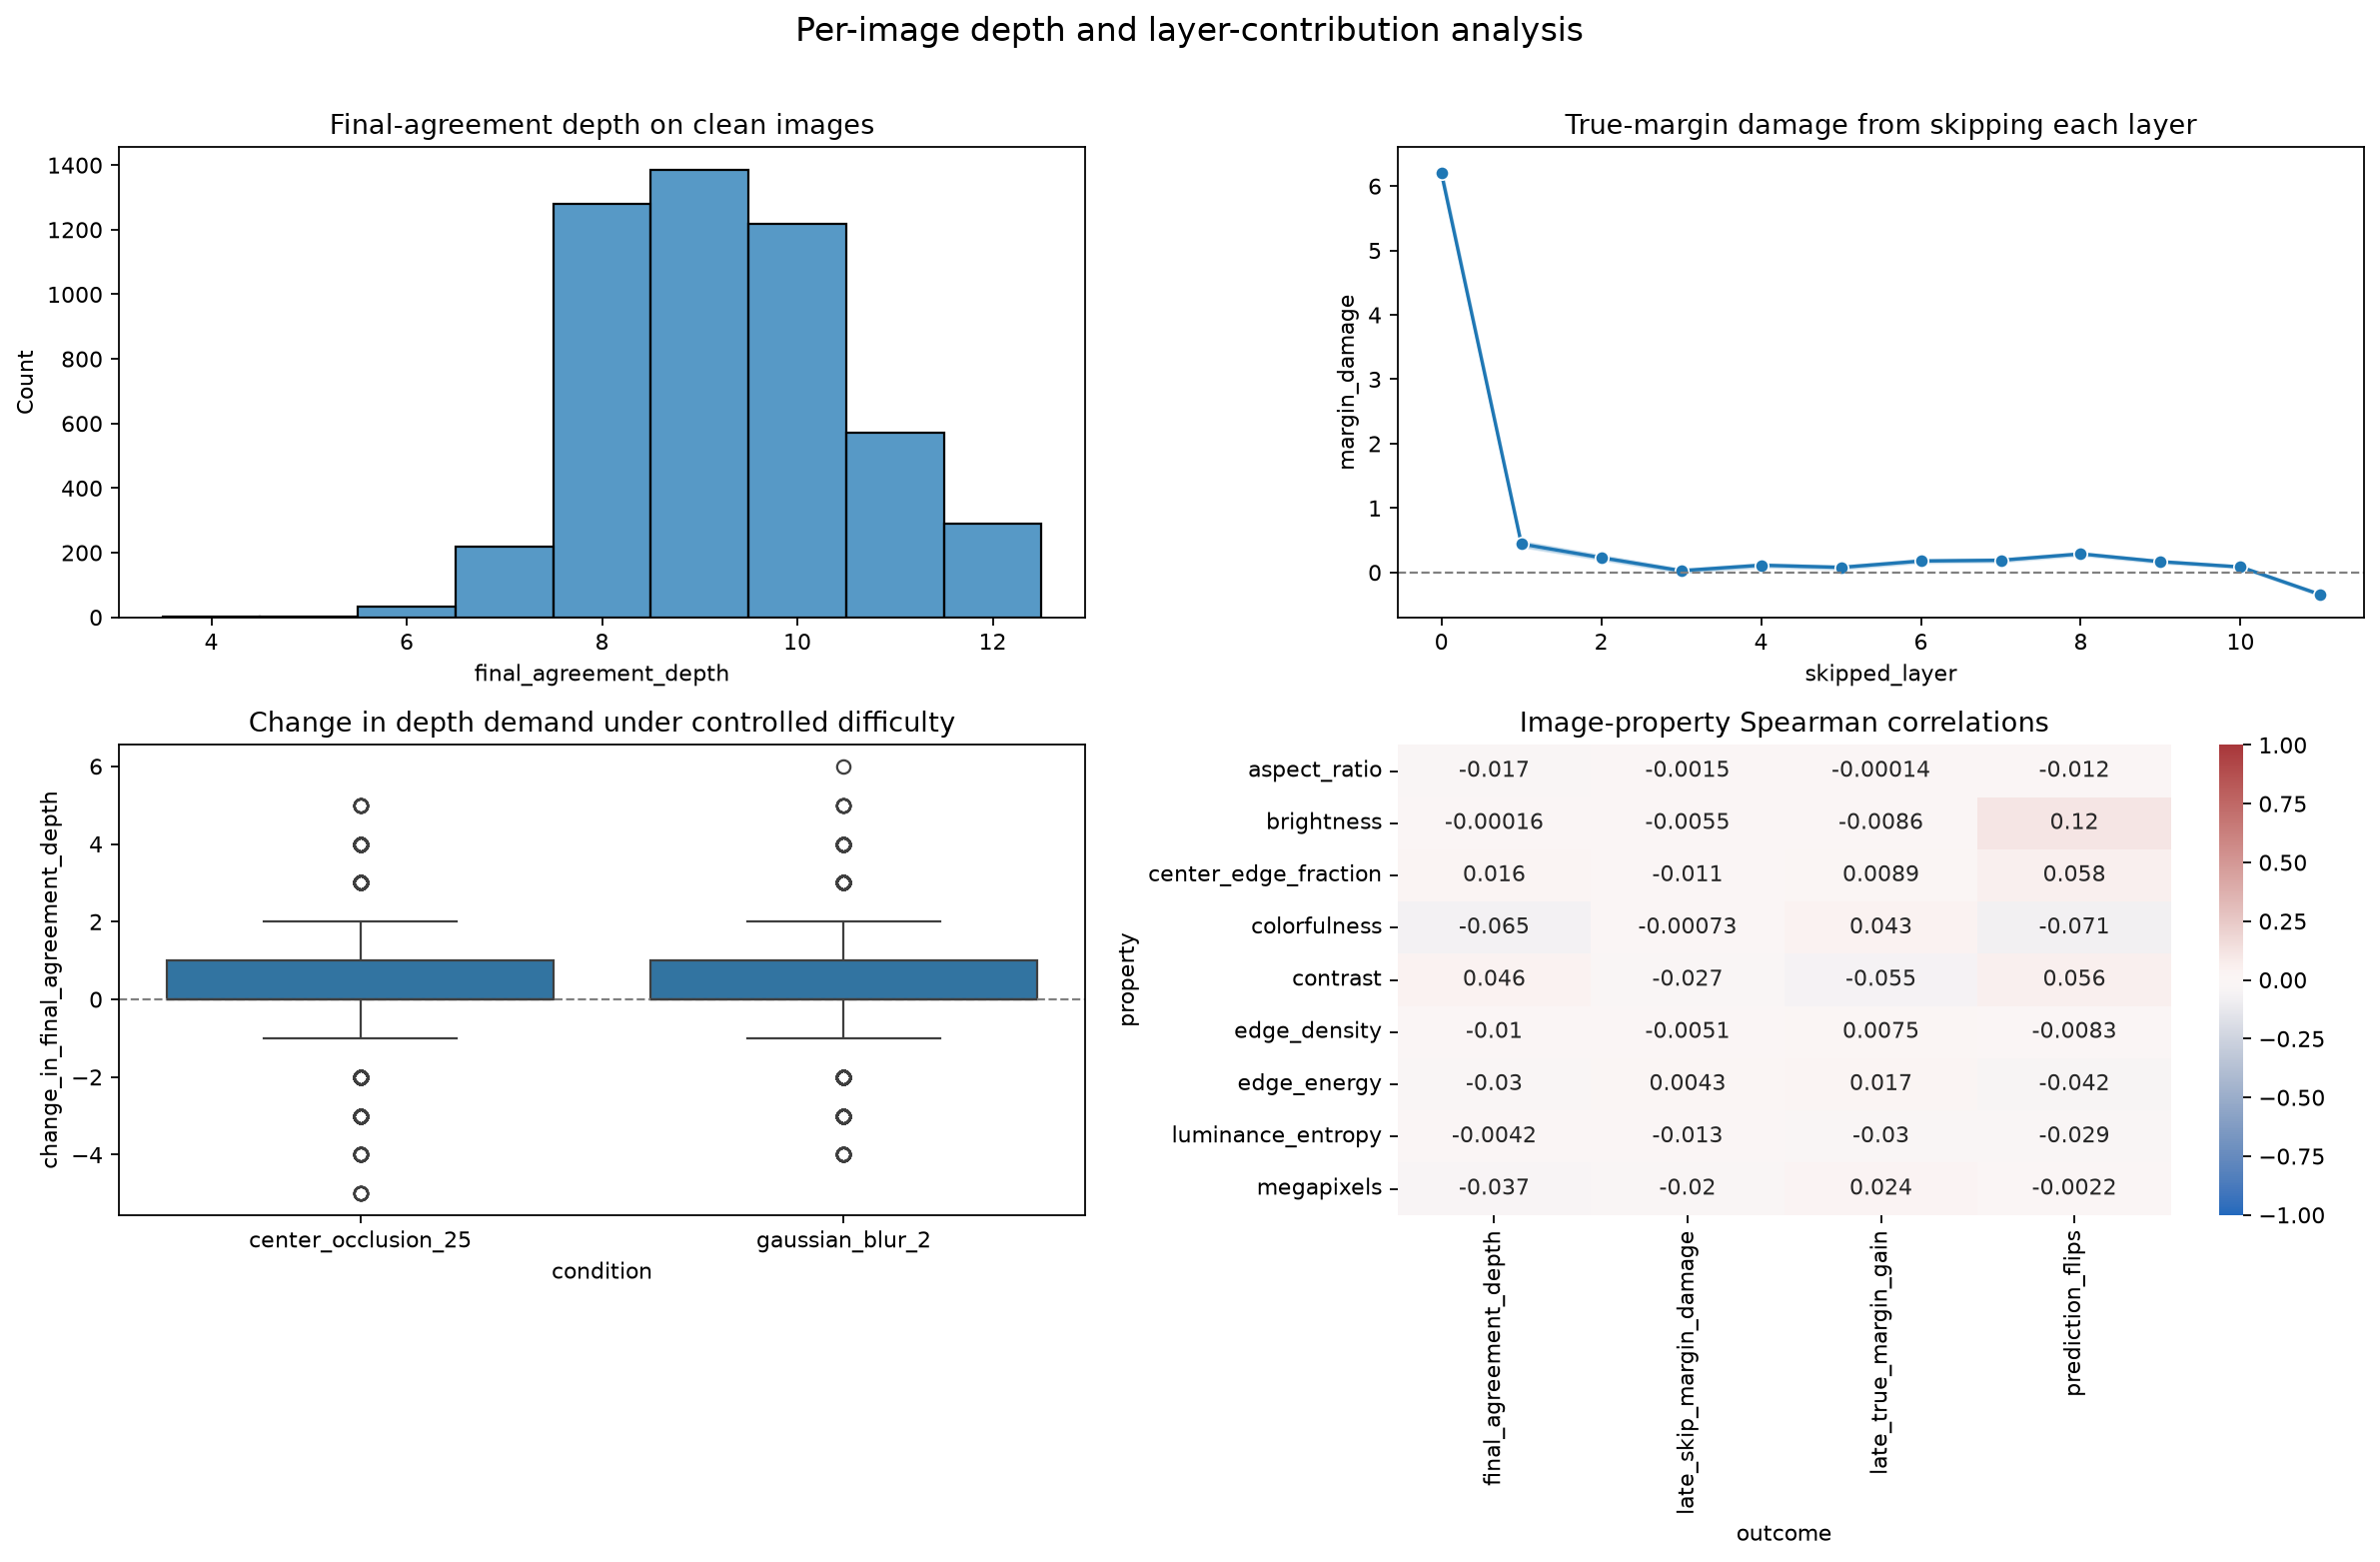

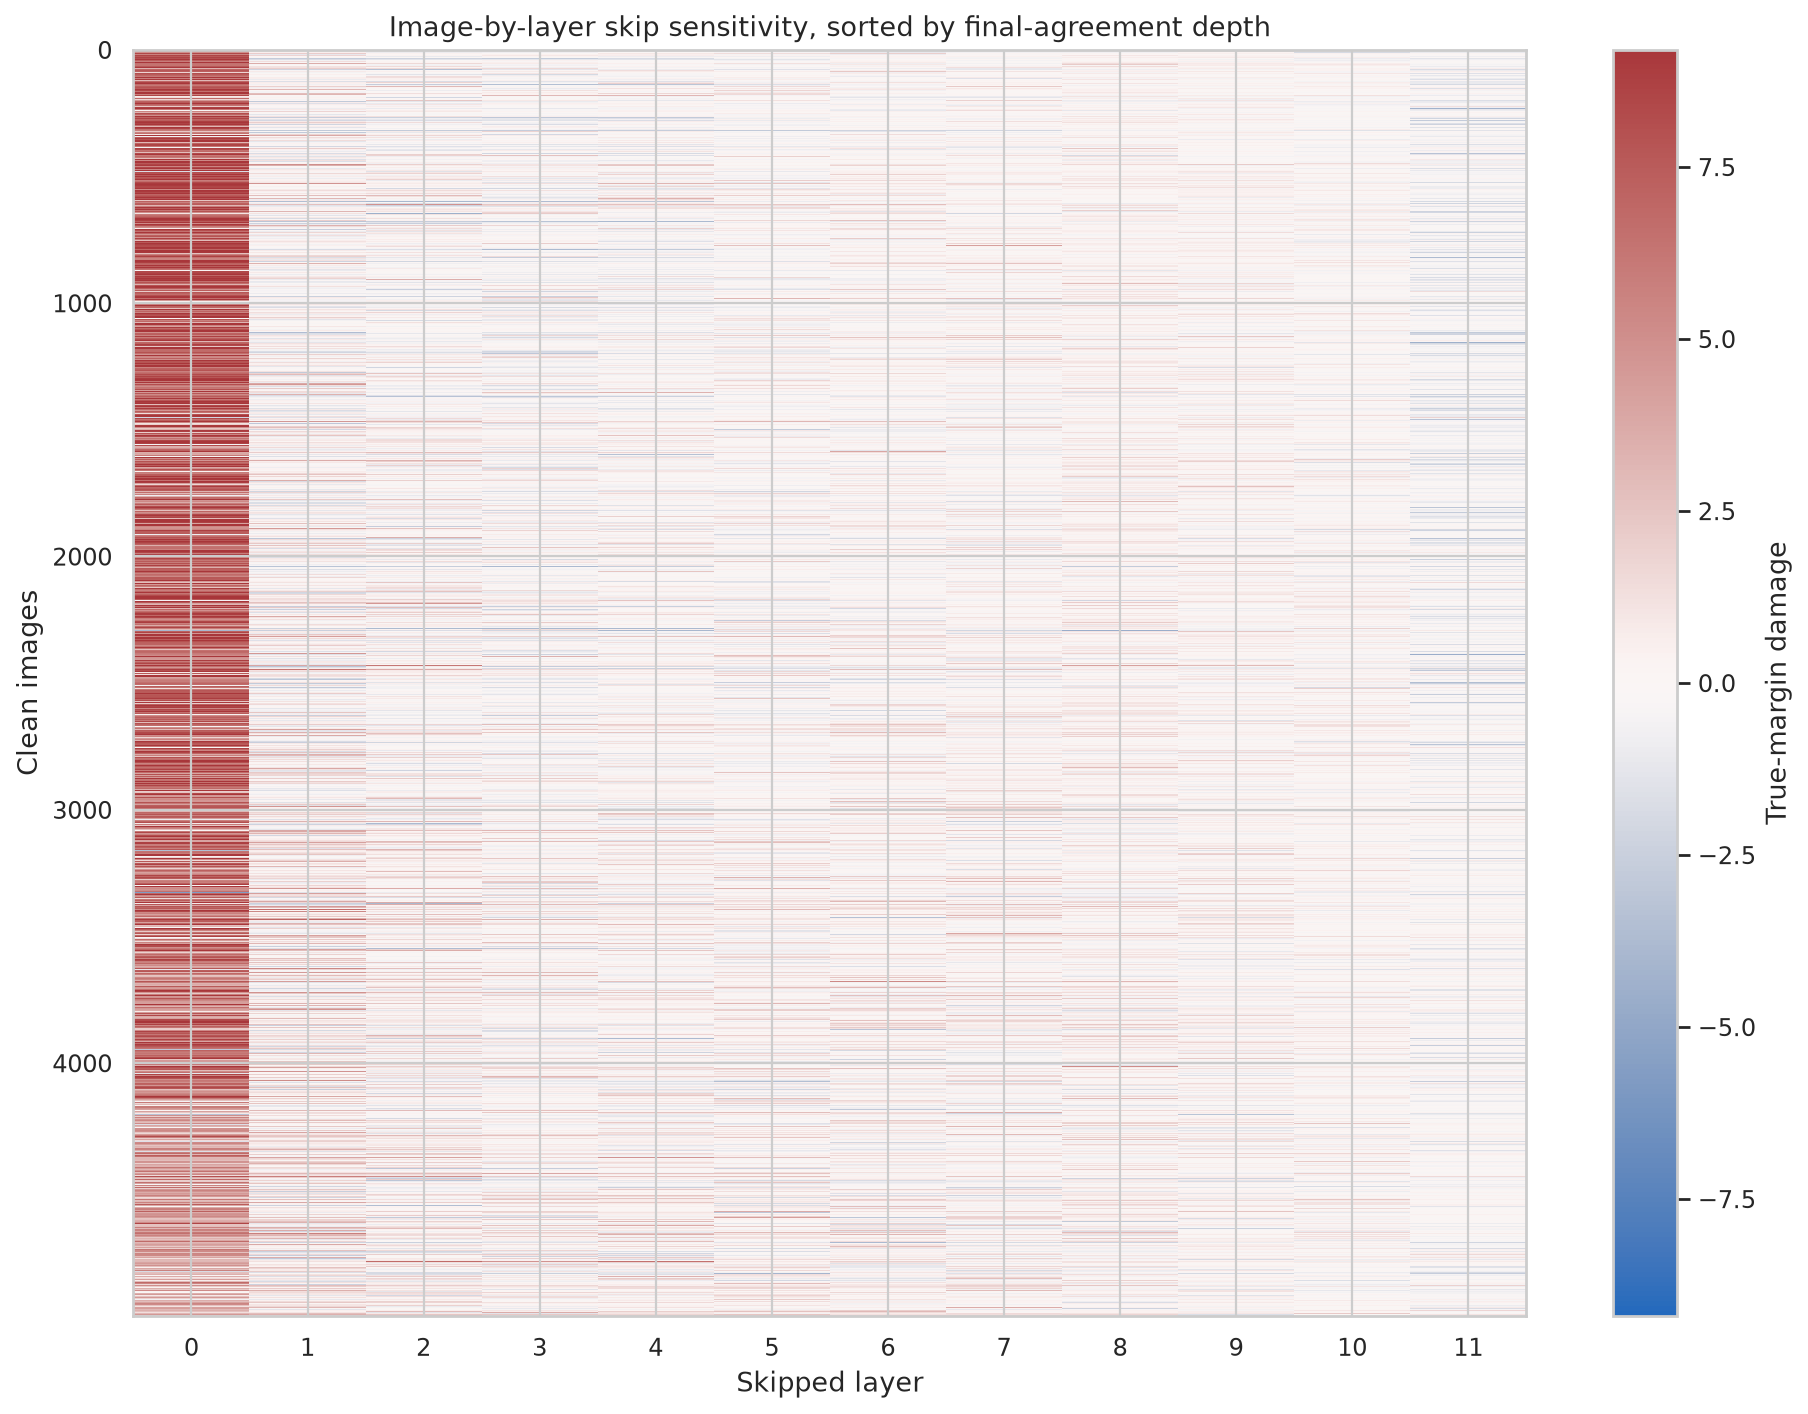

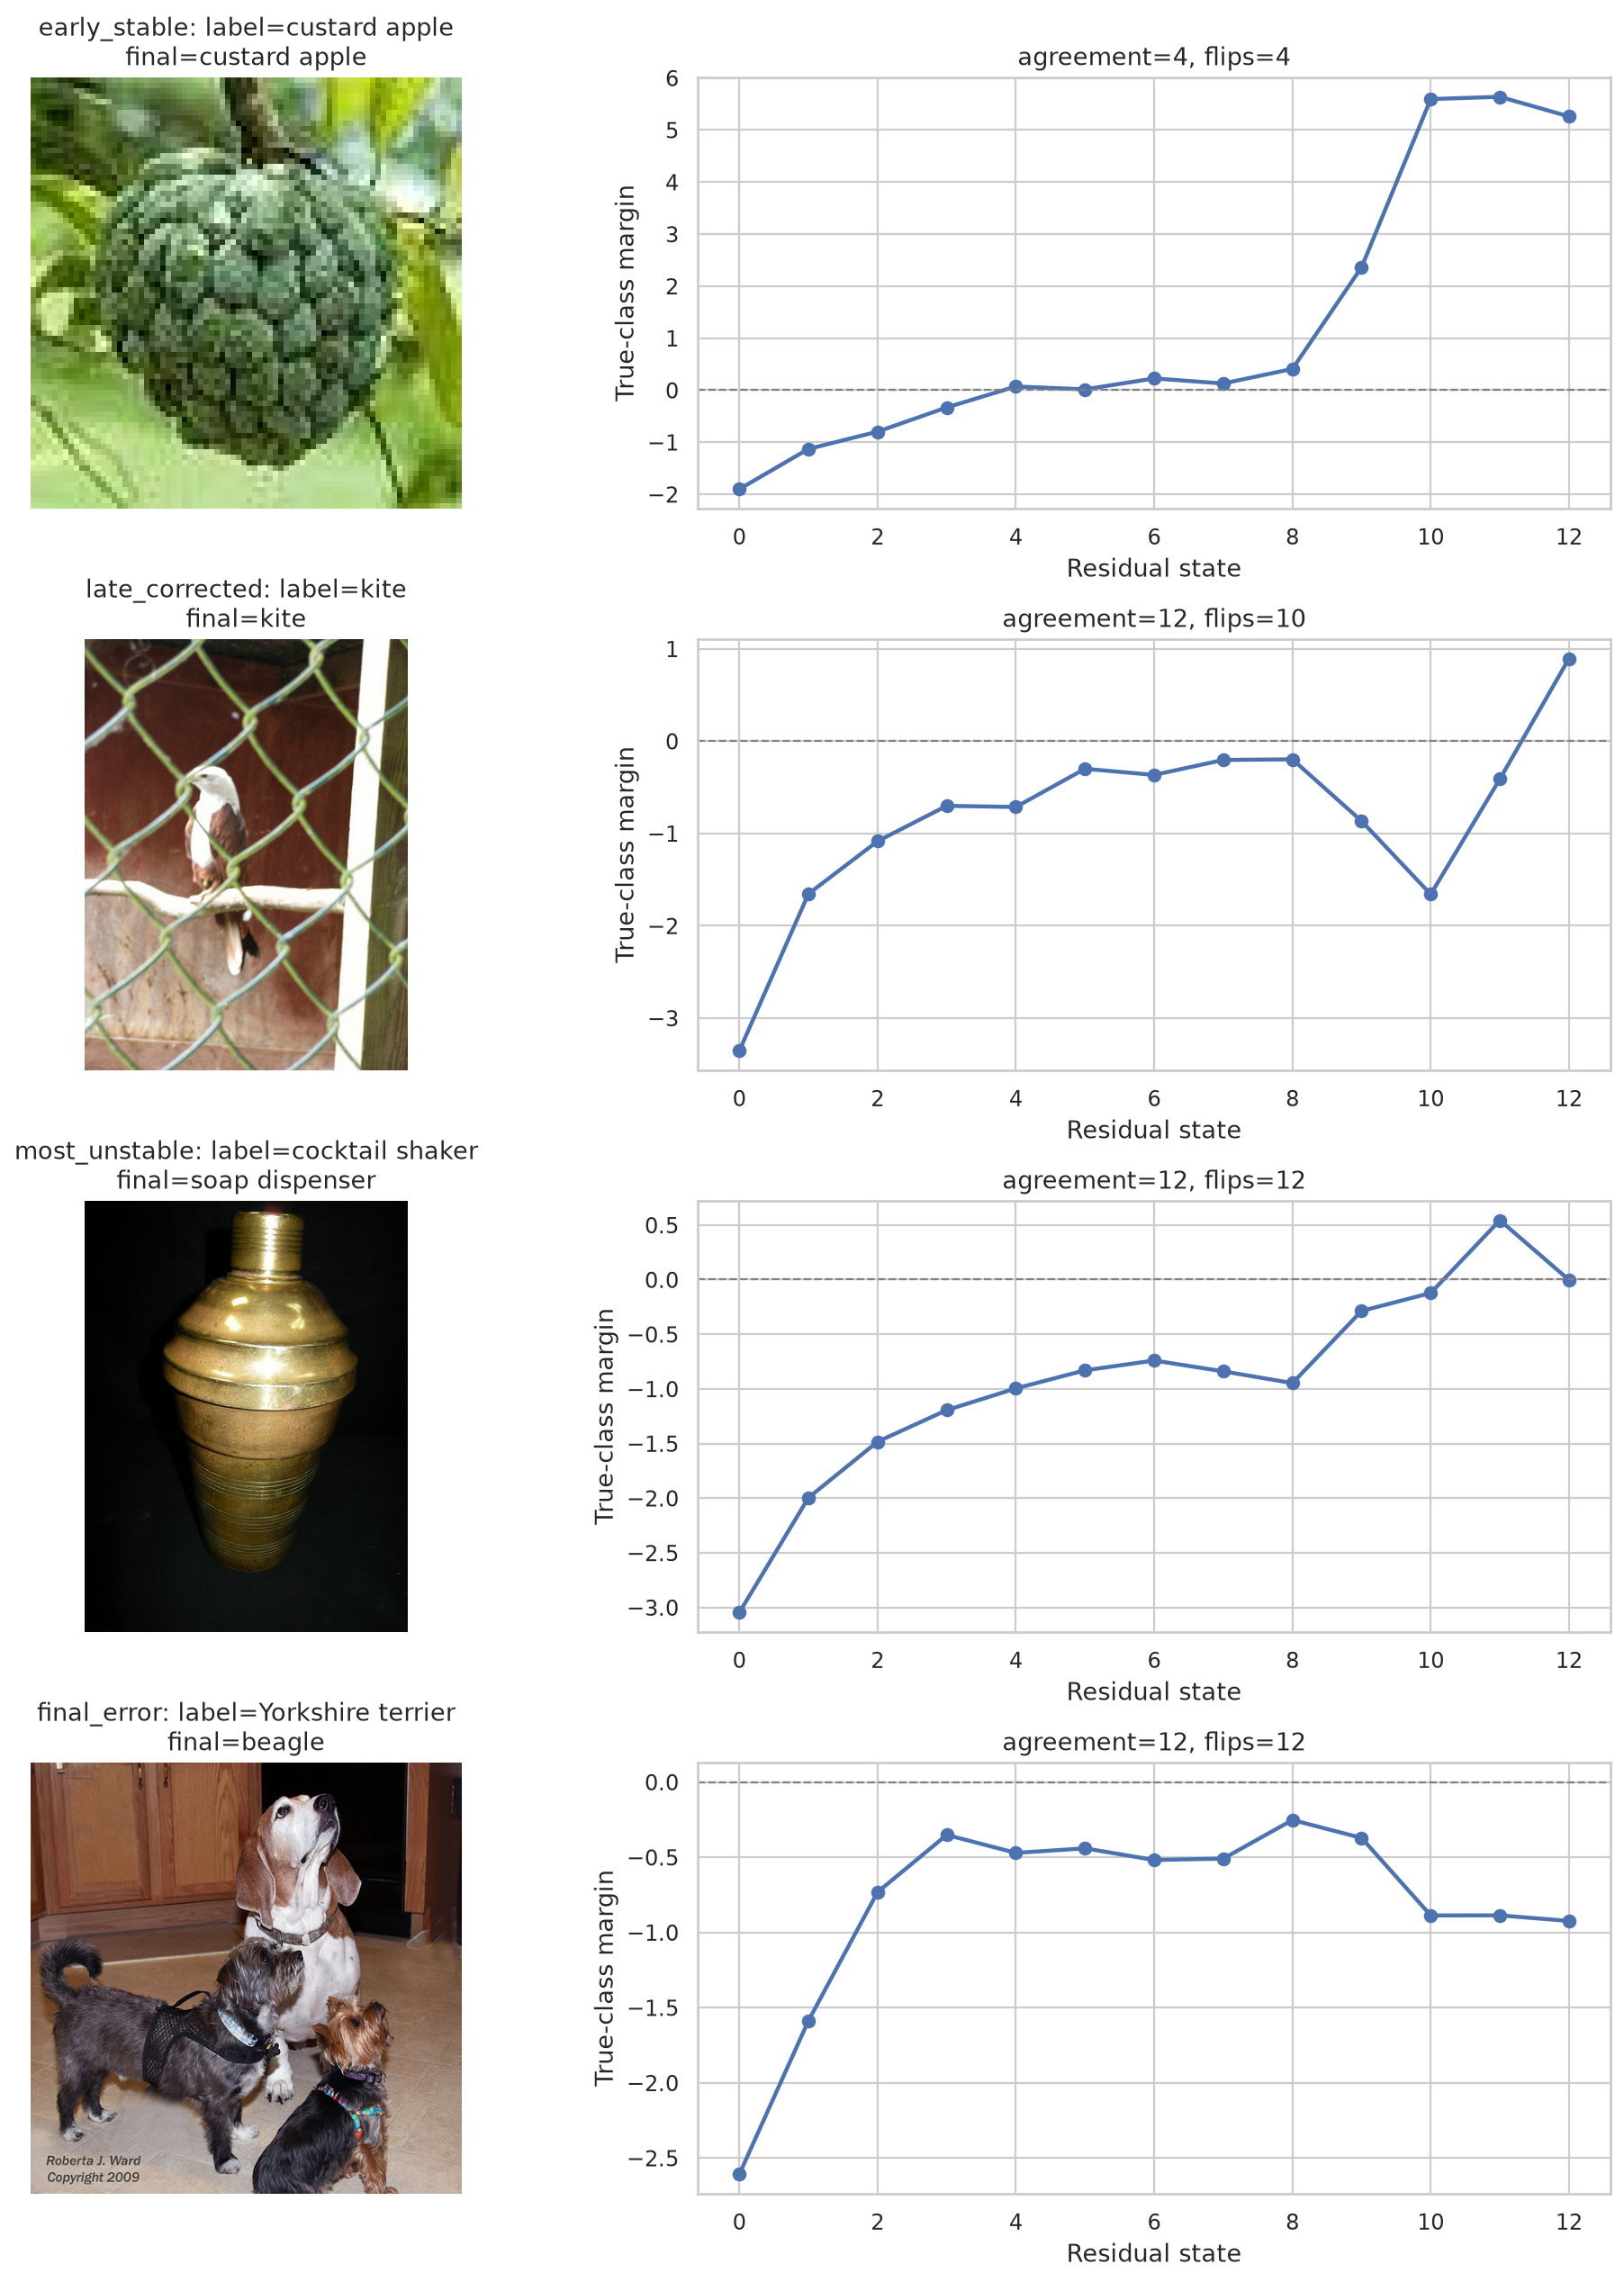

In [6]:
for figure_name in ("summary_report", "skip_heatmap", "representatives"):
    display(Image(filename=str(analysis_result["paths"][figure_name])))
